In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [1]:
import sklearn
from sklearn.decomposition import PCA

## 12/13 te photon absorption at on-reso

In [810]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []

    for p in range(num_of_ph_amp):
        
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_base = waveform_zero_fogi[p][n]
            offset=np.mean(y_absorbed)
            offset1=np.mean(y_base)
        
            E = 0
            E1 = 0
    
            for t in range(len(x)-3-50):
                t = t + 50
                E = E + ((y_absorbed[t]-offset)**2)*2
                E1 = E1 + ((y_base[t]-offset1)**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state

In [ ]:
#photon number
ph_amp = 3 #0-8
freq_if = 1.2173913e+08
readout_lo_freq = 10.423e9
duration = 260
atten_dB = -55.62 -50 #fridge + attenuater + R.T. wiring
atten =  10**((atten_dB)/10)
x = np.linspace(0, duration, duration)
y = square(freq_if, (1 + 0.5 * ph_amp) * 0.05, duration)

E = 0
for t in range(int(duration/2)):
    E = E + (y[2*t]**2)*2e-9

P_vna = 7.6e-6

photon_number = E*P_vna * atten/ (2*np.pi*hbar*(readout_lo_freq-freq_if))
plt.plot(x, y)
print(photon_number)

In [573]:
header = "D:/K_sunada/result/CDY152/"
#square
data_square="/2023-12-13/2023-12-13T223637_a391a785-731_JPA_ab_sq_waveform_qstate copy"
#time-reversed
data_tr="/2023-12-13/2023-12-13T191710_c71728ec-74_JPA_ab_tr_waveform_qstate"
#time-unreersed
data_utr="/2023-12-14/2023-12-14T093557_bf6254b4-74_JPA_ab_tr_waveform_qstate"

square

<Figure size 1000x1000 with 0 Axes>

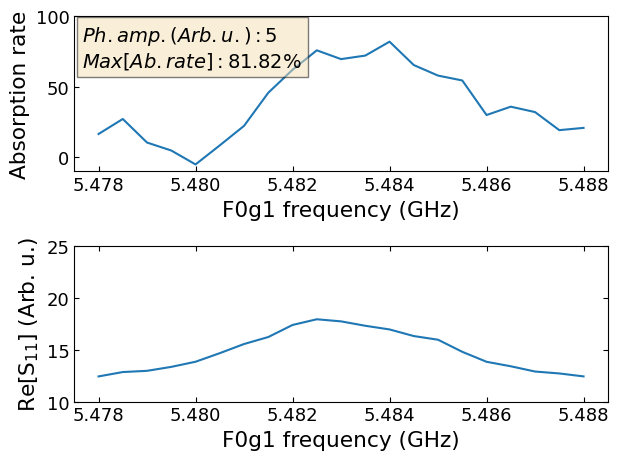

In [750]:
## absorption rate
ph_amp = 5
fogi_freq = 0
###############################################
data = data_square
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(10, 25)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

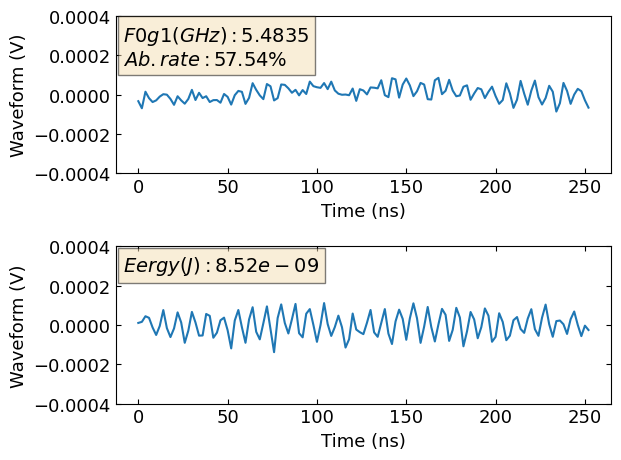

In [797]:
## waveform
ph_amp = 1
fogi_freq = 11
###############################################
data = data_square
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq][0:-3],  d[2][ph_amp][fogi_freq][0:-3])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0004, 0.0004)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq][0:-3],  d[3][ph_amp][fogi_freq][0:-3])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0004, 0.0004)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()


time-reversed

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

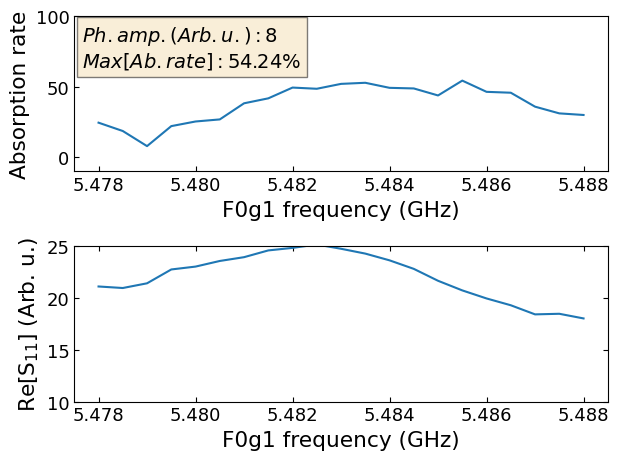

In [819]:
## absorption rate
ph_amp = 8
fogi_freq = 0
###############################################
data = data_tr
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(10, 25)

plt.tight_layout()
plt.show()

In [ ]:
ab_rate_tr = [49.58, 49.3, 70.16, 70, 71.45, 65, 63.79, 56.4, 52.52]
ab_rate_tr1 = [54.61, 61.94, 76.68, 74.05, 75.74, 70.12, 67.61, 59.81, 54.24]

<Figure size 1000x1000 with 0 Axes>

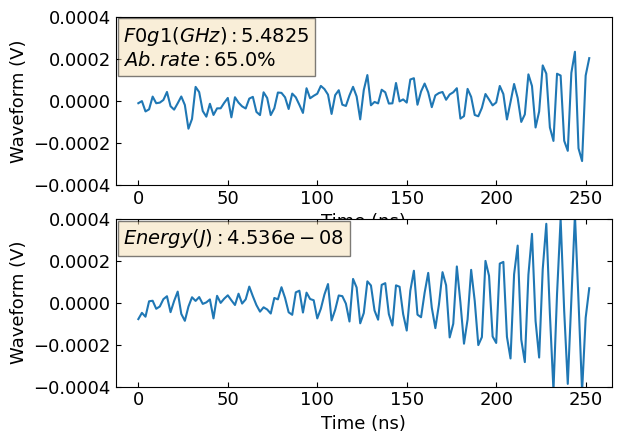

<Figure size 640x480 with 0 Axes>

In [779]:
## waveform
ph_amp = 5
fogi_freq = 9
###############################################
data = data_tr
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq][0:-3],  d[2][ph_amp][fogi_freq][0:-3])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0004, 0.0004)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq][0:-3],  d[3][ph_amp][fogi_freq][0:-3])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0004, 0.0004)
textstr1 = r"$Energy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)

plt.show()
plt.tight_layout()

time-unreversd

<Figure size 1000x1000 with 0 Axes>

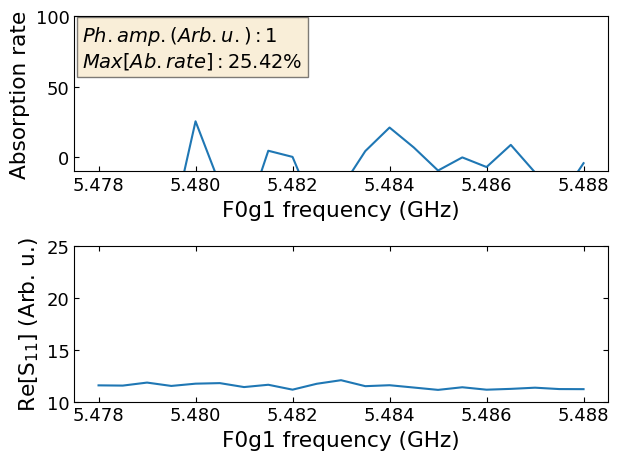

In [791]:
## absorption rate
ph_amp = 1
fogi_freq = 0
###############################################
data = data_utr
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
ax2.set_ylim(10, 25)

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

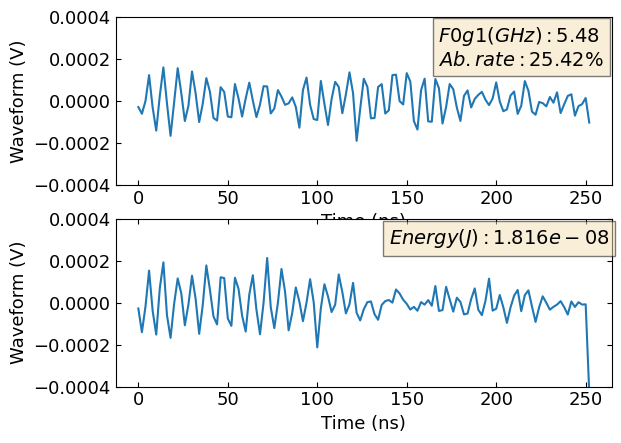

<Figure size 640x480 with 0 Axes>

In [796]:
## waveform
ph_amp = 1
fogi_freq = 4
###############################################
data = data_utr
num_of_ph_amp = 9
num_of_fogi_freq = 21
###############################################
d = data_acquisition(header, data,num_of_ph_amp, num_of_fogi_freq)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq][0:-3],  d[2][ph_amp][fogi_freq][0:-3])#-np.mean(y_absorbed))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0004, 0.0004)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.65, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq][0:-3],  d[3][ph_amp][fogi_freq][0:-3])# - np.mean(y_base))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0004, 0.0004)
textstr1 = r"$Energy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.55, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)

plt.show()
plt.tight_layout()

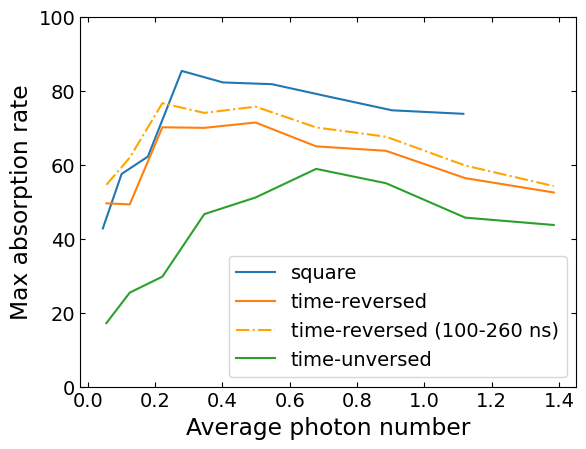

In [825]:
ab_rate_squ = [42.8, 57.54, 62.23, 85.41, 82.29, 81.82, 78.48, 74.75, 73.8]
energy_squ = [5.2e-7, 9.32e-7, 1.41e-6, 2.167e-6, 3.178e-6, 4.102e-6, 5.771e-6, 7.17e-6, 9.169e-6]

ab_rate_tr = [49.58, 49.3, 70.16, 70, 71.45, 65, 63.79, 56.4, 52.52]
ab_rate_tr1 = [54.61, 61.94, 76.68, 74.05, 75.74, 70.12, 67.61, 59.81, 54.24]
energy_tr = [5.91e-7, 1.051e-6, 1.859e-6, 2.206e-6, 3.408e-6, 4.384e-6, 5.88e-6, 7.356e-6, 9.323e-6]

ab_rate_utr = [17.18, 25.42, 29.74, 46.66, 51.16, 58.9, 55.02, 45.71, 43.72]
energy_utr = [8.74e-07, 1.061e-06, 2.106e-06, 2.862e-06, 4.122e-06, 5.351e-06, 6.563e-06, 8.972e-06, 1.0677e-05]

pn_squ = [0.0446, 0.1004, 0.1785, 0.2789, 0.4016, 0.5467, 0.7140, 0.9037, 1.1156]
pn_tr = [0.0553, 0.1245, 0.2214, 0.3460, 0.4982, 0.6782, 0.8858, 1.121, 1.384]

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 14
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax1.tick_params(top='on',bottom='on`',left='on',right='on',)
# plt.plot(np.array(energy_squ)/100, ab_rate_squ, label='square')
plt.plot(np.array(pn_squ), ab_rate_squ, label='square')
# plt.plot(np.array(energy_tr)/100, ab_rate_tr, label='time-reversed')
plt.plot(np.array(pn_tr), ab_rate_tr, label='time-reversed')
# plt.plot(np.array(energy_tr)/100, ab_rate_tr1,"-.",  label='time-reversed (100-260 ns)', color ='orange')
plt.plot(np.array(pn_tr), ab_rate_tr1,"-.",  label='time-reversed (100-260 ns)', color ='orange')
# plt.plot(np.array(energy_utr)/100, ab_rate_utr, label='time-unversed')
plt.plot(np.array(pn_tr), ab_rate_utr, label='time-unversed')
ax1.set_xlabel('Average photon number', size='large')
ax1.set_ylabel('Max absorption rate', size='large')
plt.legend()
ax1.set_ylim(0, 100)
plt.show()

## 12/6 time-reversed photon absorption

absorption rate - fogi & photon

In [10]:
def photon_energy(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    f = dd['fogi_frequency']['values'][i]
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i] #- dd['waveform1']['values']
    y_base = dd['waveform_zero_fogi']['values'][i]
    offset=np.mean(y_absorbed)
    offset1=np.mean(y_base)

    E = 0
    E1 = 0
    t = 0
  
    for t in range(len(x)):
        E = E + ((y_absorbed[t]-offset)**2)*2
        E1 = E1 + ((y_base[t]-offset1)**2)*2
    rate = 1 - E/E1
    
    return rate

In [ ]:
def acquire_photon_energy(data):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]

    f = dd['fogi_frequency']['values']
    for i in range(len(f)):
        x = dd['time']['values'][i]
        y_absorbed = dd['waveform']['values'][i] #- dd['waveform1']['values']
        y_base = dd['waveform_zero_fogi']['values'][i]
        offset=np.mean(y_absorbed)
        offset1=np.mean(y_base)
        
        E = 0
        E1 = 0
        t = 0
    
        for t in range(len(x)):
            E = E + ((y_absorbed[t]-offset)**2)*2
            E1 = E1 + ((y_base[t]-offset1)**2)*2
        rate = 1 - E/E1

        rates = np.append(rates, rate * 100)
    

    return rates

In [11]:
def waveform_show1(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    f = dd['fogi_frequency']['values'][i]
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i]
    y_base = dd['waveform_zero_fogi']['values'][i]

    plt.rcParams["font.size"] = 15
    fig = plt.figure(figsize=(10, 10))
    fig, (ax0, ax1) = plt.subplots(nrows=2)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y_absorbed)#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( -0.0005, 0.002)

    # ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y_base)# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim( -0.0005, 0.002)

    plt.tick_params(top='on',bottom='on`',left='on',right='on',)
    plt.show()
    rate = photon_energy(data, i) * 100

    plt.tight_layout()
    return rate , f

## 73

In [12]:
def acquire_photon_energy(data):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]

    f = dd['fogi_frequency']['values']
    for i in range(len(f)):
        x = dd['time']['values'][i]
        y_absorbed = dd['waveform']['values'][i] #- dd['waveform1']['values']
        y_base = dd['waveform_zero_fogi']['values'][i]
        offset=np.mean(y_absorbed)
        offset1=np.mean(y_base)
        
        E = 0
        E1 = 0
        t = 0
    
        for t in range(len(x)):
            E = E + ((y_absorbed[t]-offset)**2)*2
            E1 = E1 + ((y_base[t]-offset1)**2)*2
        rate = 1 - E/E1

        rates = np.append(rates, rate * 100)
    

    return rates

In [13]:
def waveform_show1(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    f = dd['fogi_frequency']['values'][i]
    x = dd['time']['values'][i]
    y_absorbed = dd['waveform']['values'][i]# - dd['waveform1']['values']
    y_base = dd['waveform_zero_fogi']['values'][i]
    # y2 = dd['waveform2']['values']

    plt.rcParams["font.size"] = 15
    fig = plt.figure(figsize=(10, 10))
    fig, (ax0, ax1) = plt.subplots(nrows=2)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y_absorbed)#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( -0.0005, 0.002)

    # ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y_base)# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim( -0.0005, 0.002)


    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    rate = photon_energy(data, i) * 100

    plt.tight_layout()
    return rate , f

## 74
fogi freq / photon amp sweep (3D)

In [6]:
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-05/2023-12-05T213232_5c9f33a9-74_JPA_ab_time_reversed_waveform_qstate"
dd = datadict_from_hdf5(header+data+"/data")

In [115]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [301]:
def acquire_photon_energy3D(data, a): #a: photon amplitude id
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]
    area=[]

    waveform = []
    waveform_zero_fogi = []
    time = []
    fogi_freq = []
    for i in range(10):
        k = i* 16
        f = dd['fogi_frequency']['values'][k:k+15]
        t = dd['time']['values'][k:k+15]
        w = dd['waveform']['values'][k:k+15]
        wf = dd['waveform_zero_fogi']['values'][k:k+15]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)

 
    for n in range(len(fogi_freq[0])):
        x = time[a][n]
        y_absorbed = waveform[a][n]
        y_base = waveform_zero_fogi[a][n]
        offset=np.mean(y_absorbed)
        offset1=np.mean(y_base)
        
        E = 0
        E1 = 0
        t = 0
    
        for t in range(len(x)-3):
            E = E + ((y_absorbed[t]-offset)**2)*2
            E1 = E1 + ((y_base[t]-offset1)**2)*2
        rate = 1 - E/E1
        area=np.append(area, E1)
        rates = np.append(rates, rate * 100)
    
    return rates, area

In [328]:
def waveform_show3D(data, a, f): #a: ph amp, f: fogi freq
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    waveform = []
    waveform_zero_fogi = []
    time = []
    fogi_freq = []
    for i in range(10):
        k = i* 16
        fs = dd['fogi_frequency']['values'][k:k+15]
        ts = dd['time']['values'][k:k+15]
        ws = dd['waveform']['values'][k:k+15]
        wfs = dd['waveform_zero_fogi']['values'][k:k+15]
        fogi_freq.append(fs)
        time.append(ts)
        waveform.append(ws)
        waveform_zero_fogi.append(wfs)

    freq = fogi_freq[a][f]
    x = time[a][f]
    y_absorbed = waveform[a][f]
    y_base = waveform_zero_fogi[a][f]
    
    plt.rcParams["font.size"] = 15
    fig = plt.figure(figsize=(10, 10))
    fig, (ax0, ax1) = plt.subplots(nrows=2)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x[0:-3],  y_absorbed[0:-3])#-np.mean(y_absorbed))
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    # ax0.set_xlim( 0, 1000)
    ax0.set_ylim( 0.00045, 0.00085)

    # ax1.set_title("no absorption")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x[0:-3],  y_base[0:-3])# - np.mean(y_base))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    # ax1.set_xlim( 0, 1000)    
    ax1.set_ylim(0.00045, 0.00085)

    plt.tick_params(top='on',bottom='on`',left='on',right='on')
    plt.show()
    rate = acquire_photon_energy3D(data, a)[0][f]
    area = acquire_photon_energy3D(data, a)[1][f]

    plt.tight_layout()
    return rate , freq, x, y_base, area

## square photon

<Figure size 1000x1000 with 0 Axes>

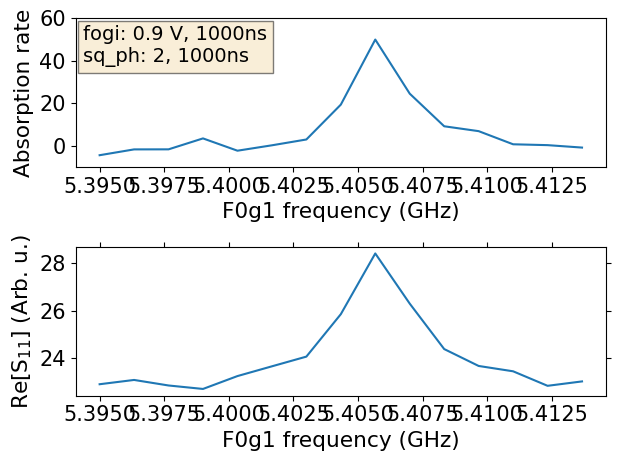

In [290]:
#square off reso 1000ns
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-07/2023-12-07T150326_55e60f63-731_JPA_ab_sq_waveform_qstate copy"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(4):
    k = i* 16
    f = dd['fogi_frequency']['values'][k:k+15]
    q = dd['qstate']['values'][k:k+15].real
    fogi_freq.append(f)
    q_state.append(q)
 
m = 2 ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)[0]

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((
    'fogi: 0.9 V, 1000ns',
    'sq_ph: 2, 1000ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-10, 60)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
# print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

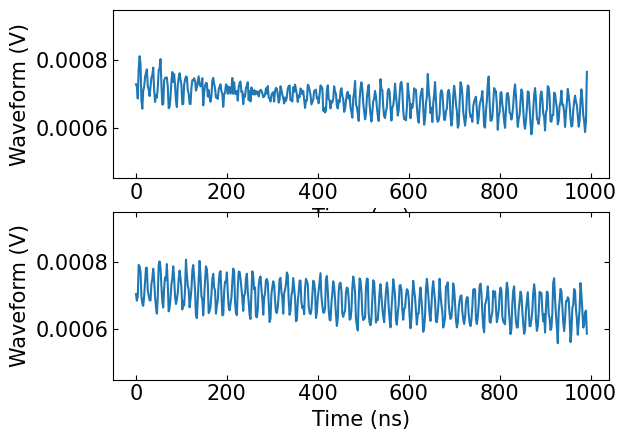

(34.11287315128071,
 5.407,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338, 340, 342, 

<Figure size 640x480 with 0 Axes>

In [295]:
waveform_show3D(data, 0, 9)

## time_reversed photon1

-original photon:

    Fogi: 5.42

    Photon: 10.346 

-reflected photon:

    Fogi: 5.395
    
    Photon:10.355

<Figure size 1000x1000 with 0 Axes>

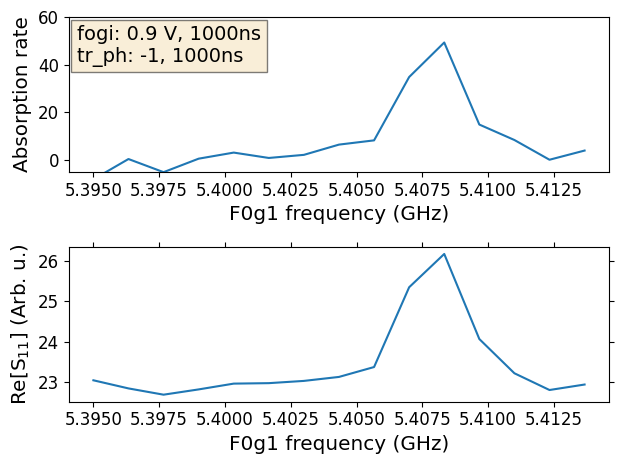

5.413666666666667 3.914690792301412


In [326]:
#tuika
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-07/2023-12-07T193049_b07440ca-74_JPA_ab_tr_waveform_qstate"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(10):
    k = i* 16
    f = dd['fogi_frequency']['values'][k:k+15]
    q = dd['qstate']['values'][k:k+15].real
    fogi_freq.append(f)
    q_state.append(q)


    
m = 0 ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)[0]

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 12
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
            )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 1000ns',
    'tr_ph: -1, 1000ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-5, 60)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

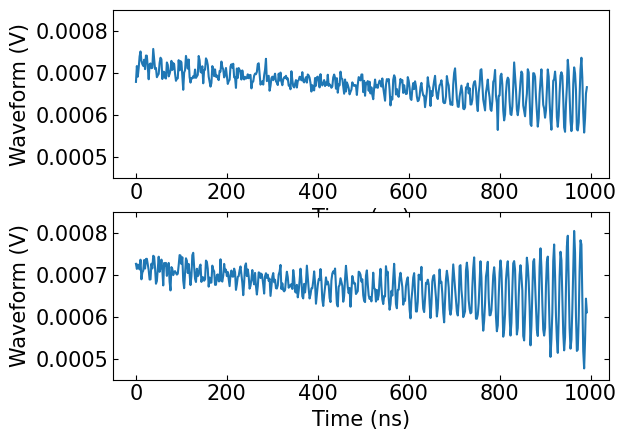

(49.28875774433392,
 5.408333333333333,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338

<Figure size 640x480 with 0 Axes>

In [329]:
waveform_show3D(data, 0, 10)

<Figure size 1000x1000 with 0 Axes>

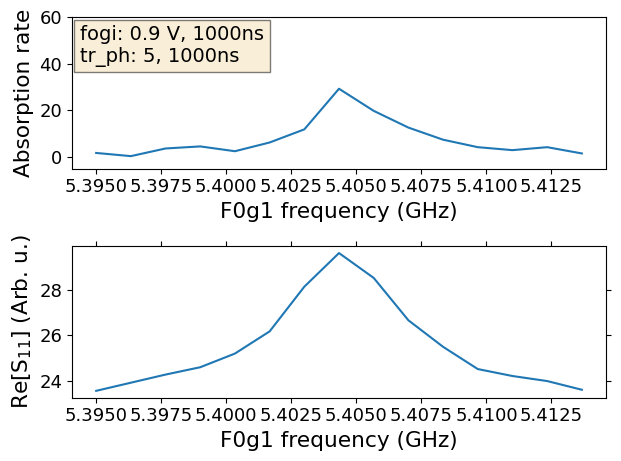

5.413666666666667 1.4754509830809392


In [306]:
#
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-07/2023-12-07T082722_0196267a-741_JPA_ab_waveform_qstate"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(10):
    k = i* 16
    f = dd['fogi_frequency']['values'][k:k+15]
    q = dd['qstate']['values'][k:k+15].real
    fogi_freq.append(f)
    q_state.append(q)
    
m = 5 ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)[0]

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
            )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 1000ns',
    'tr_ph: 5, 1000ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-5, 60)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

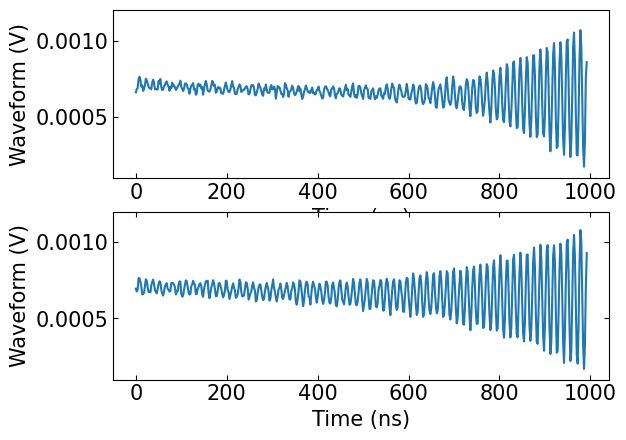

(29.22541891421152,
 5.404333333333333,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338

<Figure size 640x480 with 0 Axes>

In [309]:
waveform_show3D(data, 5, 7)

<Figure size 1000x1000 with 0 Axes>

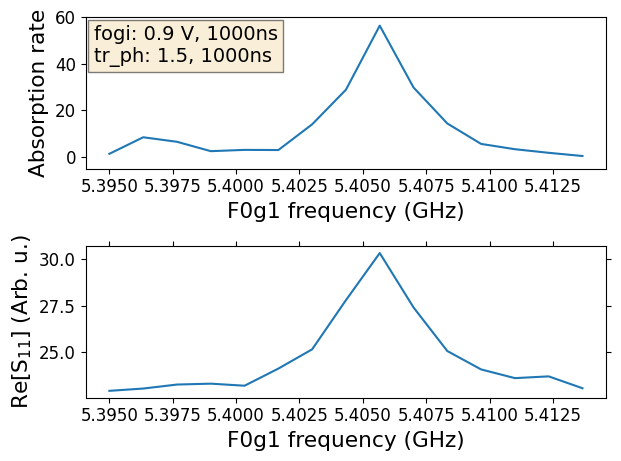

5.413666666666667 0.3747986428680128


In [316]:
data = "/2023-12-07/2023-12-07T173432_71a7ab7e-74_JPA_ab_tr_waveform_qstate"
#
header = "D:/K_sunada/result/CDY152/"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(10):
    k = i* 16
    f = dd['fogi_frequency']['values'][k:k+15]
    q = dd['qstate']['values'][k:k+15].real
    fogi_freq.append(f)
    q_state.append(q)


    
m = 0 ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)[0]

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
            )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 1000ns',
    'tr_ph: 1.5, 1000ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(-5, 60)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

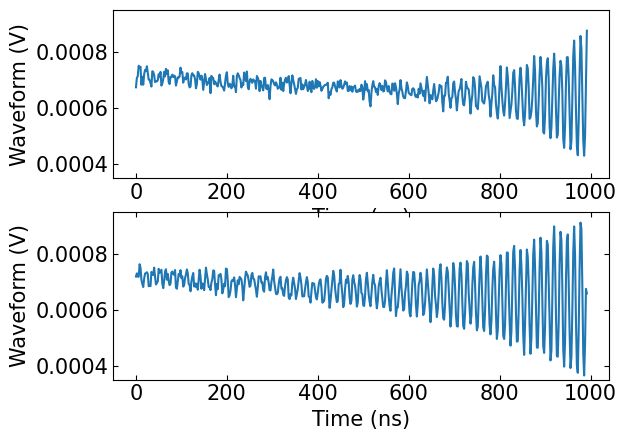

(56.29104585368001,
 5.405666666666667,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338

<Figure size 640x480 with 0 Axes>

In [320]:
waveform_show3D(data, 0, 8)

<Figure size 1000x1000 with 0 Axes>

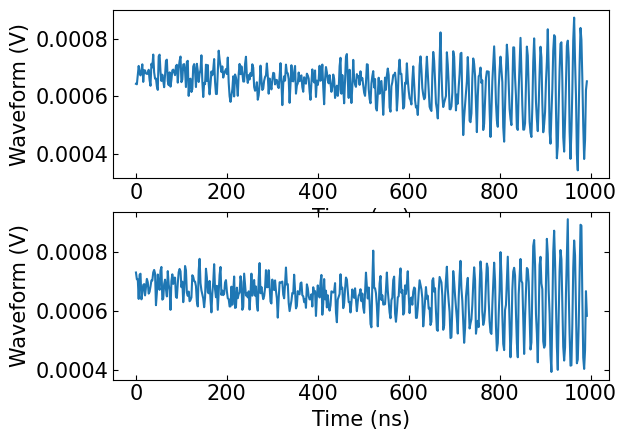

(2.4087035377683086,
 5.4,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338, 340, 342, 3

<Figure size 640x480 with 0 Axes>

In [125]:
data = "/2023-12-05/2023-12-05T213232_5c9f33a9-74_JPA_ab_time_reversed_waveform_qstate"
waveform_show3D(data, 3, 0)

<Figure size 1000x1000 with 0 Axes>

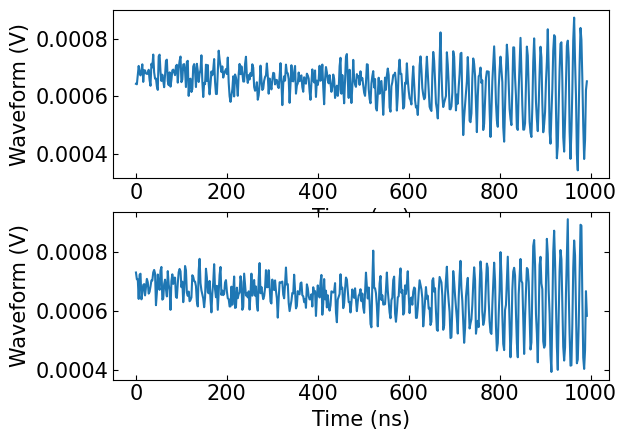

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

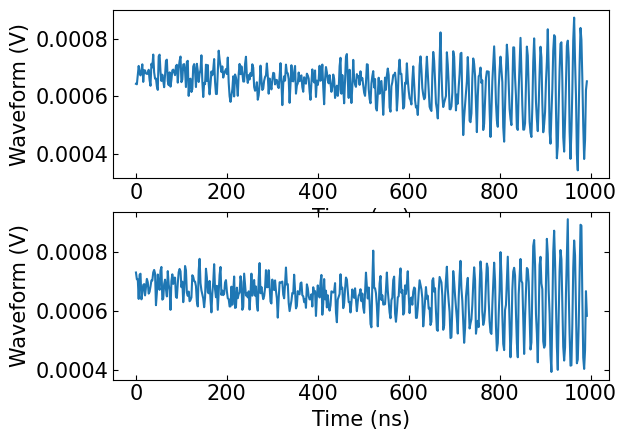

[1.0491e+10 1.0355e+10]


<Figure size 640x480 with 0 Axes>

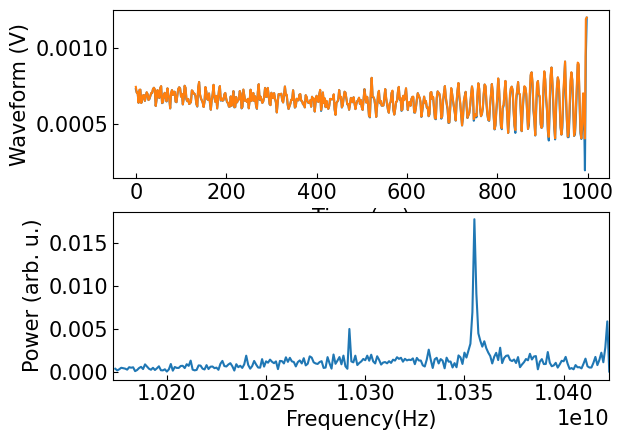

In [126]:
x = waveform_show3D(data, 3, 0)[2]
y = waveform_show3D(data, 3, 0)[3]

readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(x,  y)
ax1.plot(x, np.abs(signal.hilbert(y)))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('Frequency(Hz)')
ax2.set_ylabel('Power (arb. u.)')
ax2.plot(readout_lo_freq-x_fft, y_fft)

ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
# ax2.set_xlim(0, 250e6)
ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]
print(peak)

In [150]:
#
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-06/2023-12-06T114143_fd9c6be3-74_JPA_ab_time_reversed_waveform_qstate"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(20):
    k = i* 31
    f = dd['fogi_frequency']['values'][k:k+30]
    q = dd['qstate']['values'][k:k+30].real
    fogi_freq.append(f)
    q_state.append(q)


    
m = 6  ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
            )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 200ns',
    'ph: 0.38 V, 200ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
print(f[14], ab_rate[14])

IndexError: list index out of range

<Figure size 1000x1000 with 0 Axes>

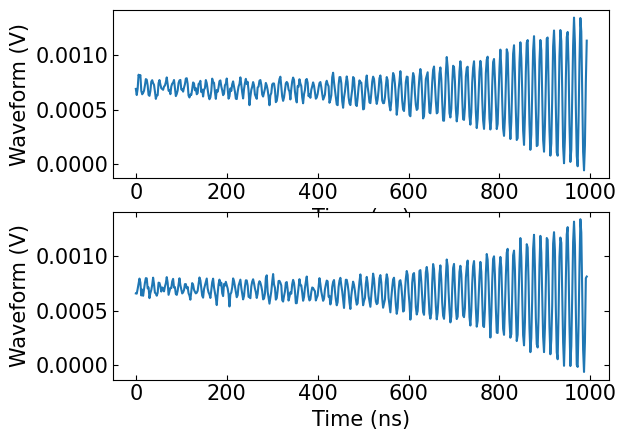

(-0.7471600829294767,
 5.4,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338, 340, 342, 

<Figure size 640x480 with 0 Axes>

In [128]:
data =  "/2023-12-06/2023-12-06T114143_fd9c6be3-74_JPA_ab_time_reversed_waveform_qstate"
waveform_show3D(data, 6, 15)

In [ ]:
x = waveform_show3D(data, 0, 5)[2]
y = waveform_show3D(data, 0, 5)[3]

readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(x,  y)
ax1.plot(x, np.abs(signal.hilbert(y)))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('Frequency(Hz)')
ax2.set_ylabel('Power (arb. u.)')
ax2.plot(readout_lo_freq-x_fft, y_fft)

ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
# ax2.set_xlim(0, 250e6)
ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]
print(peak)

<Figure size 1000x1000 with 0 Axes>

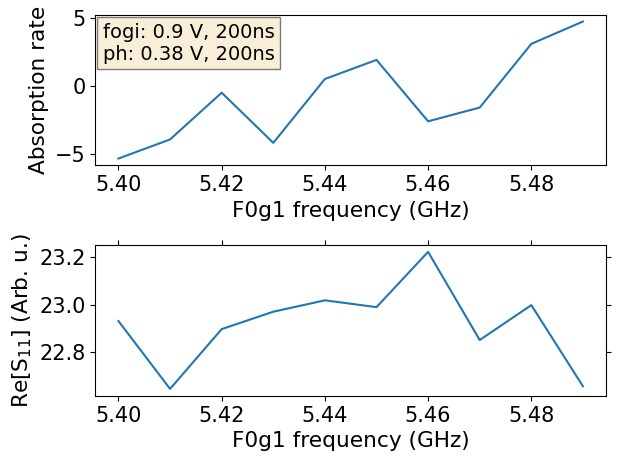

In [148]:
# square
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-06/2023-12-06T181753_55e68d4f-74_JPA_ab_time_reversed_waveform_qstate"
dd = datadict_from_hdf5(header+data+"/data")

fogi_freq = []
q_state =[]
for i in range(5):
    k = i* 11
    f = dd['fogi_frequency']['values'][k:k+10]
    q = dd['qstate']['values'][k:k+10].real
    fogi_freq.append(f)
    q_state.append(q)


    
m = 1  ##photon amp id
f = fogi_freq[m]
qstate = q_state[m]
ab_rate = acquire_photon_energy3D(data, m)

fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
            )
textstr1 = '\n'.join((
    'fogi: 0.9 V, 200ns',
    'ph: 0.38 V, 200ns'
))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.plot(f, ab_rate)
ax1.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)

ax2.plot(f, qstate)
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(20, 35)

plt.tight_layout()
plt.show()
# print(f[14], ab_rate[14])

<Figure size 1000x1000 with 0 Axes>

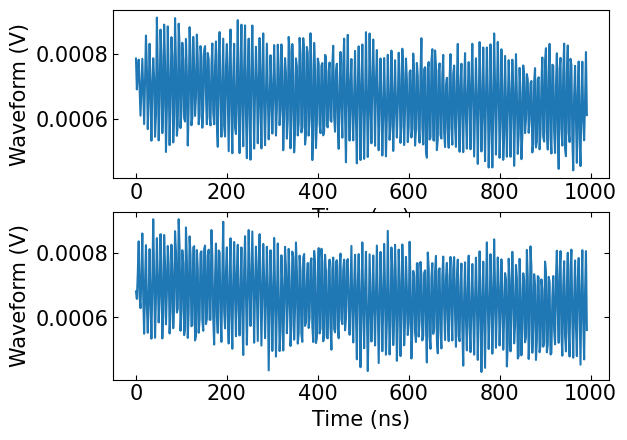

(-2.3073126243393416,
 5.45,
 array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
         26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
         52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
         78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100, 102,
        104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128,
        130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154,
        156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180,
        182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206,
        208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232,
        234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258,
        260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284,
        286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310,
        312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336,
        338, 340, 342,

<Figure size 640x480 with 0 Axes>

In [146]:
waveform_show3D(data, 0, 5)

<Figure size 1000x1000 with 0 Axes>

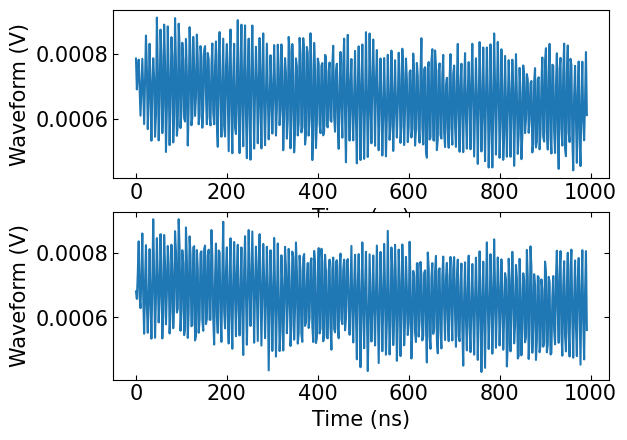

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

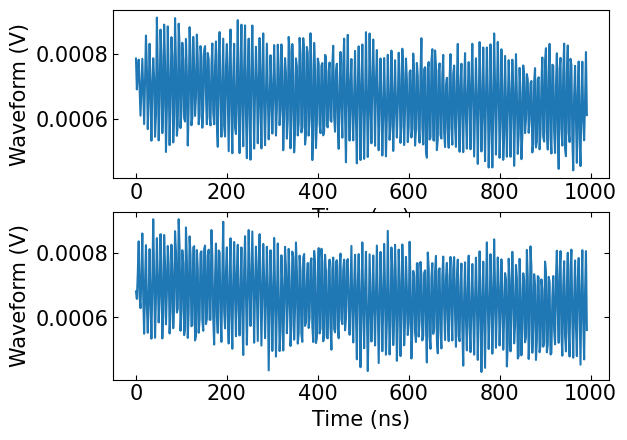

[1.0547e+10 1.0299e+10]


<Figure size 640x480 with 0 Axes>

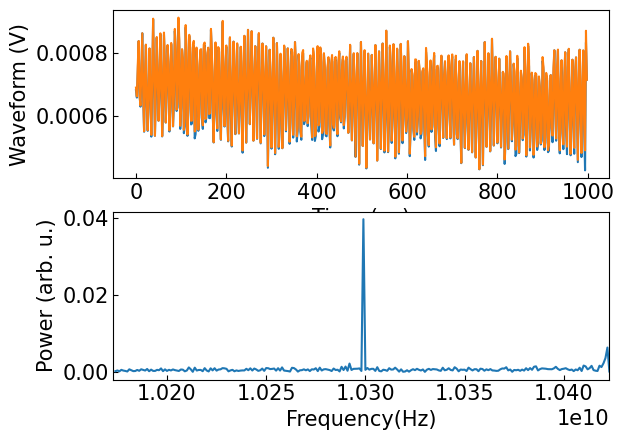

In [147]:
x = waveform_show3D(data, 0, 5)[2]
y = waveform_show3D(data, 0, 5)[3]

readout_freq = 10.306e9
readout_if_freq = (10.423-10.306)*1e9
readout_lo_freq = readout_freq + readout_if_freq

x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(x,  y)
ax1.plot(x, np.abs(signal.hilbert(y)))
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('Frequency(Hz)')
ax2.set_ylabel('Power (arb. u.)')
ax2.plot(readout_lo_freq-x_fft, y_fft)

ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
# ax2.set_xlim(0, 250e6)
ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]
print(peak)

## 12/11

In [362]:
def acquire_photon_energy3D(data, a): #a: photon amplitude id
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    rates=[]
    energy=[]

    fogi_freq= dd['fogi_frequency']['values']
    time = dd['time']['values']
    waveform = dd['waveform']['values']
    waveform_zero_fogi = dd['waveform_zero_fogi']['values']

    x = time[a]
    y_absorbed = waveform[a]
    y_base = waveform_zero_fogi[a]
    offset=np.mean(y_absorbed)
    offset1=np.mean(y_base)
        
    E = 0
    E1 = 0
    t = 0
    
    for t in range(len(x)-3):
        E = E + ((y_absorbed[t]-offset)**2)*2
        E1 = E1 + ((y_base[t]-offset1)**2)*2
    rate = 1 - E/E1
    energy=np.append(energy, E1)
    rates = np.append(rates, rate * 100)
    
    return rates, energy

In [372]:
#square - phamp and energy
# square
header = "D:/K_sunada/result/CDY152/"
data = "/2023-12-11/2023-12-11T103041_e5ca4142-731_JPA_ab_sq_waveform_qstate copy"
dd = datadict_from_hdf5(header+data+"/data")

acquire_photon_energy3D(data, 0)[1], acquire_photon_energy3D(data, 1)[1],acquire_photon_energy3D(data, 2)[1],acquire_photon_energy3D(data, 3)[1], acquire_photon_energy3D(data, 4)[1]

(array([5.77428822e-07]),
 array([3.7544822e-05]),
 array([0.00014348]),
 array([0.00031667]),
 array([0.00056062]))

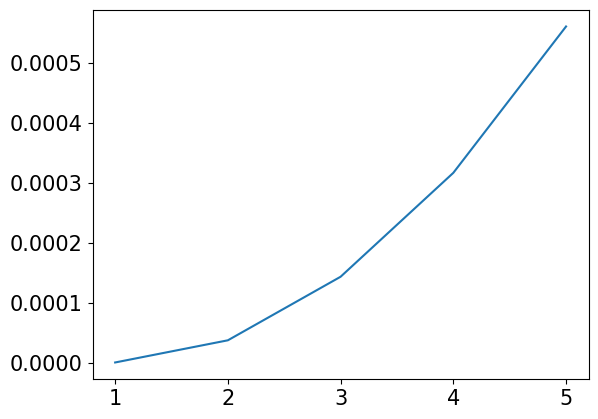

In [373]:
x = [1, 2, 3, 4, 5] #DAC amp
y = [acquire_photon_energy3D(data, 0)[1], acquire_photon_energy3D(data, 1)[1],acquire_photon_energy3D(data, 2)[1],acquire_photon_energy3D(data, 3)[1], acquire_photon_energy3D(data, 4)[1]]
plt.plot(x, y)